In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import numpy as np
import re
from pandas.api.types import is_categorical_dtype

CARGAMOS DATAFRAME 2005 

In [2]:
df05 = pd.read_stata("Individual_t105.dta")
df05

,CODUSU,nro_hogar,componente,h15,ano4,trimestre,region,mas_500,aglomerado,pondera,...,deccfr,ideccfr,rdeccfr,gdeccfr,pdeccfr,adeccfr,pj1_1,pj2_1,pj3_1,idimpp
0,125098,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1017.0,...,08,,07,08,,05,0.0,0.0,0.0,00000
1,125188,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1062.0,...,02,,02,02,,01,0.0,0.0,0.0,40020
2,125188,1.0,2.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1062.0,...,02,,02,02,,01,0.0,0.0,0.0,00000
3,125188,1.0,3.0,0.0,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1062.0,...,02,,02,02,,01,0.0,0.0,0.0,00000
4,125242,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1103.0,...,09,,09,09,,07,0.0,0.0,0.0,00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47025,288015,1.0,3.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,129.0,...,09,10,09,,10,07,0.0,0.0,0.0,00000
47026,288015,1.0,4.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,129.0,...,09,10,09,,10,07,0.0,0.0,0.0,00000
47027,288294,1.0,1.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,107.0,...,10,10,09,,10,09,0.0,0.0,0.0,00000
47028,288294,1.0,2.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,107.0,...,10,10,09,,10,09,0.0,0.0,0.0,00000


NORMALIZAMOS LAS VARIABLES DE 2005

In [3]:
def _norm_str(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = "".join(c for c in unicodedata.normalize("NFKD", x) if not unicodedata.combining(c))
    return x.lower()

def _coerce_object_if_categorical(s: pd.Series) -> pd.Series:
    """Si la serie es Categorical -> la paso a object para poder asignar nuevos valores."""
    return s.astype("object") if is_categorical_dtype(s) else s

def _map_text_to_codes(series, mapping, valid=None):
    s = _coerce_object_if_categorical(series.copy())
    is_num = pd.to_numeric(s, errors="coerce")

    mapping_norm = { _norm_str(k): v for k, v in mapping.items() }

    s_text = s[is_num.isna()]
    if not s_text.empty:
        s.loc[s_text.index] = s_text.map(lambda v: mapping_norm.get(_norm_str(v), np.nan))

    s = pd.to_numeric(s, errors="coerce")

    if valid is not None:
        s = s.where(s.isin(valid), np.nan)
        return s.astype("Int64")

    return s

def _menos_de_un_ano_to_zero(series):
    s = _coerce_object_if_categorical(series.copy())
    def is_menos(v):
        if pd.isna(v): return False
        t = _norm_str(v)
        pats = [
            r"^menos\s+de\s+1\s*ano$",
            r"^menos\s+de\s+un\s*ano$",
            r"^menor\s+de\s+1\s*ano$",
            r"^<\s*1$",
            r"^0\s*anos?$"
        ]
        return any(re.match(p, t) for p in pats)
    mask = s.astype(str).map(is_menos)
    s.loc[mask] = 0
    return s

# --- Identificadores: pasan como están a numérico ---
def normalize_codusu_2005(s):     return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_nro_hogar_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_componente_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pondera_2005(s):    return pd.to_numeric(s, errors="coerce")  # peso puede ser float

# --- Demográficas / geográficas ---
def normalize_h15_2005(s):
    mapping = {"si":1, "sí":1, "s":1, "no":2, "n":2, 1:1, 2:2}
    return _map_text_to_codes(s, mapping, valid={1,2})

def normalize_ano4_2005(s):      return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_trimestre_2005(s):
  mapping = {"1er. Trimestre":1, "2do. Trimestre":2, "3er. Trimestre":3, "4to. Trimestre":4}
  return _map_text_to_codes(s, mapping, valid={1,2,3,4}) 

def normalize_region_2005(s):
    mapping = {"gran buenos aires":1,"gba":1,"noa":40,"nea":41,"cuyo":42,"pampeana":43,"patagonica":44,"patagónica":44}
    return _map_text_to_codes(s, mapping, valid={1,40,41,42,43,44})

def normalize_mas_500_2005(s):
    mapping = {"si":1,"sí":1,"s":1,1:1,"no":0,"n":0,0:0}
    return _map_text_to_codes(s, mapping, valid={0,1})

def _norm_str(s):
    if pd.isna(s):
        return s
    s = str(s).lower()
    # acentos
    s = (s.replace("á","a").replace("é","e").replace("í","i")
           .replace("ó","o").replace("ú","u").replace("ü","u"))
    # unificar guiones y signos raros a espacio
    s = re.sub(r'[-–—_/]', ' ', s)
    # eliminar cualquier otra puntuación
    s = re.sub(r'[^a-z0-9 ]+', '', s)
    # colapsar espacios
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def normalize_aglomerado_2005(s):
    mapping = {
    "gran la plata": 2,
    "bahia blanca - cerri": 3, "bahía blanca - cerri": 3,
    "gran rosario": 4,
    "gran santa fe": 5,
    "gran parana": 6, "gran paraná": 6,
    "posadas": 7,
    "gran resistencia": 8,
    "cdro. rivadavia - rada tilly": 9, "comodoro rivadavia - rada tilly": 9,
    "gran mendoza": 10,
    "corrientes": 12,
    "gran cordoba": 13, "gran córdoba": 13,
    "concordia": 14,
    "formosa": 15,
    "neuquen - plottier": 17, "neuquén - plottier": 17,
    "santiago del estero - la banda": 18, "s.del estero - la banda": 18,
    "jujuy - palpala": 19, "jujuy - palpalá": 19, "jujuy - palpalá": 19,
    "rio gallegos": 20, "río gallegos": 20,
    "gran catamarca": 22,
    "salta": 23,
    "la rioja": 25,
    "san luis - el chorrillo": 26,
    "gran san juan": 27,
    "gran tucuman - t. viejo": 29, "gran tucumán - t. viejo": 29,
    "santa rosa - toay": 30,
    "ushuaia - rio grande": 31, "ushuaia - río grande": 31,
    "ciudad de buenos aires": 32, "caba": 32, "capital federal": 32,
    "partidos del gba": 33, "gba partidos": 33, "gran buenos aires partidos": 33,
    "mar del plata - batan": 34, "mar del plata - batán": 34,
    "rio cuarto": 36, "río cuarto": 36
}
    return _map_text_to_codes(s, mapping, valid={2, 3, 4, 5, 6, 7, 8, 9, 10, 
 12, 13, 14, 15, 17, 18, 19, 20, 
 22, 23, 25, 26, 27, 29, 30, 31, 
 32, 33, 34, 36})

# --- Hogar / persona ---
def normalize_ch03_2005(s):
    mapping = {"jefe":1,"jefa":1,"conyuge":2,"cónyuge":2,"pareja":2,"hijo":3,"hija":3,
               "yerno":4,"nuera":4,"nieto":5,"nieta":5,"madre":6,"padre":6,
               "suegro":7,"suegra":7,"hermano":8,"hermana":8,"otros familiares":9,"no familiares":10}
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,5,6,7,8,9,10})

def normalize_ch04_2005(s):
    mapping = {"varon":1,"varón":1,"hombre":1,"m":1,"mujer":2,"f":2,"femenino":2}
    return _map_text_to_codes(s, mapping, valid={1,2})

def normalize_ch06_2005(s):
    s = _menos_de_un_ano_to_zero(s)
    s = pd.to_numeric(s, errors="coerce")
    s = s.where(s >= 0, np.nan)
    return s.astype("Int64")

def normalize_ch07_2005(s):
    mapping = {"unido":1,"casado":2,"separado":3,"divorciado":3,"viudo":4,"soltero":5}
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,5})

def normalize_ch08_2005(s):
    mapping = {
        "obra social (incluye pami)":1,"obra social":1,
        "mutual/prepaga/servicio de emergencia":2,"mutual":2,"prepaga":2,
        "planes y seguros publicos":3,"planes y seguros públicos":3,
        "no paga ni le descuentan":4,
        "ns/nr":9,"ns. / nr.":9,"ns./nr.":9,"ns nr":9,
        "obra social y mutual/prepaga/servicio de emergencia":12,"obra social + mutual/prepaga":12,
        "obra social y planes y seguros publicos":13,"obra social + planes publicos":13,
        "mutual/prepaga/servicio de emergencia y planes y seguros publicos":23,"mutual/prepaga + planes publicos":23,
        "obra social, mutual/prepaga/servicio de emergencia y planes y seguros publicos":123,"todas":123
    }
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,9,12,13,23,123})

def normalize_ch09_2005(s):
    mapping = {"si":1,"sí":1,"no":2,"menor de 2 anos":3,"menor de 2 años":3}
    return _map_text_to_codes(s, mapping, valid={1,2,3})

def normalize_ch10_2005(s):
    mapping = {"asiste":1,"no asiste":2,"no asiste, pero asistio":2,"no asiste, pero asistió":2,"nunca asistio":3,"nunca asistió":3}
    return _map_text_to_codes(s, mapping, valid={1,2,3})

def normalize_ch11_2005(s):
    mapping = {"publico":1,"público":1,"privado":2,"ns/nr":9,"ns":9,"nr":9}
    return _map_text_to_codes(s, mapping, valid={1,2,9})

def normalize_ch12_2005(s):
    mapping = {"jardin":1,"jardín":1,"primario":2,"egb":3,"secundario":4,"polimodal":5,"terciario":6,"universitario":7,"posgrado":8,"educacion especial":9}
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,5,6,7,8,9})

def normalize_ch13_2005(s):
    mapping = {"si":1,"sí":1,"no":2,"ns/nr":9}
    return _map_text_to_codes(s, mapping, valid={1,2,9})

def normalize_ch14_2005(s):
    mapping = {"ninguno":0,"primero":1,"segundo":2,"tercero":3,"cuarto":4,"quinto":5,"sexto":6,"septimo":7,"séptimo":7,"octavo":8,"noveno":9}
    s_num = pd.to_numeric(s, errors="coerce")
    s_num = s_num.where(s_num.notna(), _map_text_to_codes(s, mapping))
    return pd.to_numeric(s_num, errors="coerce").astype("Int64")

def normalize_ch15_2005(s):
    mapping = {"esta localidad":1,"otra localidad de esta provincia":2,"otra provincia":3,"pais limitrofe":4,"país limitrofe":4,"otro pais":5,"otro país":5,"ns/nr":9}
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,5,9})

def normalize_ch16_2005(s):
    mapping = {"esta localidad":1,"otra localidad de esta provincia":2,"otra provincia":3,"pais limitrofe":4,"país limitrofe":4,"otro pais":5,"otro país":5,"no habia nacido":6,"no había nacido":6,"ns/nr":9}
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,5,6,9})

def normalize_ch15_cod_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_ch16_cod_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_nivel_ed_2005(s):
    mapping = {"primaria incompleta":1,"primario incompleto":1,"primaria completa":2,"primario completo":2,
               "secundaria incompleta":3,"secundaria completa":4,
               "superior universitaria incompleta":5,"universitaria incompleta":5,
               "superior universitaria completa":6,"universitaria completa":6,
               "sin instruccion":7,"sin instrucción":7,"ns/nr":9}
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,5,6,7,9})

def normalize_estado_2005(s):
    mapping = {"entrevista individual no realizada":0,"entrevista no realizada":0,"ocupado":1,"desocupado":2,"inactivo":3,"menor de 10 anos":4,"menor de 10 años":4}
    return _map_text_to_codes(s, mapping, valid={0,1,2,3,4})

def normalize_cat_ocup_2005(s):
    mapping = {"patron":1,"patrón":1,"cuenta propia":2,"obrero":3,"empleado":3,"obrero o empleado":3,"trabajador familiar sin remuneracion":4,"trabajador familiar sin remuneración":4,"ns/nr":9,"ns":9,"nr":9}
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,9})

def normalize_cat_inac_2005(s):
    mapping = {"jubilado/pensionado":1,"jubilado":1,"pensionado":1,"rentista":2,"estudiante":3,"ama de casa":4,"menor de 6 anos":5,"menor de 6 años":5,"discapacitado":6,"otros":7}
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,5,6,7})

# --- Búsqueda empleo / ocupación actual ---
def _yes_no(s):
    mapping = {"si":1,"sí":1,"s":1,1:1,"no":2,"n":2,0:2,2:2}
    return _map_text_to_codes(s, mapping, valid={1,2})

def normalize_pp02c1_2005(s): return _yes_no(s)
def normalize_pp02c2_2005(s): return _yes_no(s)
def normalize_pp02c3_2005(s): return _yes_no(s)
def normalize_pp02c4_2005(s): return _yes_no(s)
def normalize_pp02c5_2005(s): return _yes_no(s)
def normalize_pp02c6_2005(s): return _yes_no(s)
def normalize_pp02c7_2005(s): return _yes_no(s)
def normalize_pp02c8_2005(s): return _yes_no(s)

def normalize_pp02e_2005(s):
    mapping = {"esta suspendido":1,"está suspendido":1,"ya tiene trabajo asegurado":2,"se canso de buscar trabajo":3,"se cansó de buscar trabajo":3,"hay poco trabajo en esta epoca del ano":4,"hay poco trabajo en esta época del año":4,"otras razones":5}
    return _map_text_to_codes(s, mapping, valid={1,2,3,4,5})

def normalize_pp02h_2005(s): return _yes_no(s)
def normalize_pp02i_2005(s): return _yes_no(s)

def normalize_pp03c_2005(s):
    mapping = {"un solo empleo":1,"un solo empleo/ocupacion/actividad":1,"uno":1,"1":1,1:1,
               "mas de un empleo":2,"más de un empleo":2,"2":2,2:2}
    return _map_text_to_codes(s, mapping, valid={1,2})

def normalize_pp03d_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp3e_tot_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp3f_tot_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp03g_2005(s):   return _yes_no(s)

# Campos adicionales de ocupación/ingresos (dejan numérico)
def normalize_pp03h_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp03i_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp03j_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_intensi_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")

# --- Fechas y códigos ocupacionales (numéricos) ---
def normalize_pp04a_2005(s):        return _yes_no(s)
def normalize_pp04b_cod_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp04b1_2005(s):       return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp04b2_2005(s):       return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp04b3_mes_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp04b3_ano_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp04b3_dia_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp04c_2005(s):        return _yes_no(s)
def normalize_pp04c99_2005(s):      return _yes_no(s)
def normalize_pp04d_cod_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp04g_2005(s):        return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_pp05b2_mes_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp05b2_ano_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp05b2_dia_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp05c_1_2005(s):      return _yes_no(s)
def normalize_pp05c_2_2005(s):      return _yes_no(s)
def normalize_pp05c_3_2005(s):      return _yes_no(s)
def normalize_pp05e_2005(s):        return _yes_no(s)
def normalize_pp05f_2005(s):        return _yes_no(s)
def normalize_pp05h_2005(s):        return _yes_no(s)

def normalize_pp06a_2005(s):        return _yes_no(s)
def normalize_pp06c_2005(s):        return _yes_no(s)
def normalize_pp06d_2005(s):        return _yes_no(s)
def normalize_pp06e_2005(s):        return _yes_no(s)
def normalize_pp06h_2005(s):        return _yes_no(s)

def normalize_pp07a_2005(s):        return _yes_no(s)
def normalize_pp07c_2005(s):        return _yes_no(s)
def normalize_pp07d_2005(s):        return _yes_no(s)
def normalize_pp07e_2005(s):        return _yes_no(s)

# listas de rubros/razones (muchas dummies): de momento, numéricas si ya vienen codificadas
def normalize_pp07f1_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07f2_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07f3_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07f4_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07f5_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07g1_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07g2_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07g3_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07g4_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07g_59_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07h_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07i_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07j_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp07k_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_pp08d1_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp08d4_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp08f1_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp08f2_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp08j1_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp08j2_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp08j3_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_pp09a_2005(s):     return _yes_no(s)
def normalize_pp09a_esp_2005(s): return s  # texto descriptivo -> mantener
def normalize_pp09b_2005(s):     return _yes_no(s)
def normalize_pp09c_2005(s):     return _yes_no(s)
def normalize_pp09c_esp_2005(s): return s  # texto descriptivo

def normalize_pp10a_2005(s): return _yes_no(s)
def normalize_pp10c_2005(s): return _yes_no(s)
def normalize_pp10d_2005(s): return _yes_no(s)
def normalize_pp10e_2005(s): return _yes_no(s)

def normalize_pp11a_2005(s):        return _yes_no(s)
def normalize_pp11b_cod_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp11b1_2005(s):       return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp11b2_mes_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp11b2_ano_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp11b2_dia_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp11c_2005(s):        return _yes_no(s)
def normalize_pp11c99_2005(s):      return _yes_no(s)
def normalize_pp11d_cod_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_pp11g_ano_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp11g_mes_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp11g_dia_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_pp11l_2005(s):  return _yes_no(s)
def normalize_pp11l1_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pp11m_2005(s):  return _yes_no(s)
def normalize_pp11n_2005(s):  return _yes_no(s)
def normalize_pp11o_2005(s):  return _yes_no(s)
def normalize_pp11p_2005(s):  return _yes_no(s)
def normalize_pp11q_2005(s):  return _yes_no(s)
def normalize_pp11r_2005(s):  return _yes_no(s)
def normalize_pp11s_2005(s):  return _yes_no(s)
def normalize_pp11t_2005(s):  return _yes_no(s)

# --- Educación/ingresos del hogar (numéricos) ---
def normalize_p21_2005(s):        return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_decocur_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_idecocur_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_rdecocur_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_gdecocur_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pdecocur_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_adecocur_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_tot_p12_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_p47t_2005(s):       return pd.to_numeric(s, errors="coerce")
def normalize_decindr_2005(s):    return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_idecindr_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_rdecindr_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_gdecindr_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pdecindr_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_adecindr_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_v2_m_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v3_m_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v4_m_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v5_m_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v8_m_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v9_m_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v10_m_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v11_m_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v12_m_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v18_m_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v19_am_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_v21_m_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_t_vi_2005(s):   return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_itf_2005(s):    return pd.to_numeric(s, errors="coerce")  # ingreso total familiar (float)
def normalize_decifr_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_idecifr_2005(s):return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_rdecifr_2005(s):return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_gdecifr_2005(s):return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pdecifr_2005(s):return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_adecifr_2005(s):return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_ipcf_2005(s):   return pd.to_numeric(s, errors="coerce")  # continua

def normalize_deccfr_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_ideccfr_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_rdeccfr_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_gdeccfr_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pdeccfr_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_adeccfr_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_pj1_1_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pj2_1_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")
def normalize_pj3_1_2005(s):  return pd.to_numeric(s, errors="coerce").astype("Int64")

def normalize_idimpp_2005(s): return pd.to_numeric(s, errors="coerce").astype("Int64")

#Wrapper
def normalize_all_2005(df):
    df = df.copy()
    fn = {
        # Identificación
        "codusu": normalize_codusu_2005,
        "nro_hogar": normalize_nro_hogar_2005,
        "componente": normalize_componente_2005,
        "pondera": normalize_pondera_2005,

        # Demográficas / geográficas
        "h15": normalize_h15_2005,
        "ano4": normalize_ano4_2005,
        "trimestre": normalize_trimestre_2005,
        "region": normalize_region_2005,
        "mas_500": normalize_mas_500_2005,
        "aglomerado": normalize_aglomerado_2005,

        # Hogar / persona
        "ch03": normalize_ch03_2005,
        "ch04": normalize_ch04_2005,
        "ch06": normalize_ch06_2005,
        "ch07": normalize_ch07_2005,
        "ch08": normalize_ch08_2005,
        "ch09": normalize_ch09_2005,
        "ch10": normalize_ch10_2005,
        "ch11": normalize_ch11_2005,
        "ch12": normalize_ch12_2005,
        "ch13": normalize_ch13_2005,
        "ch14": normalize_ch14_2005,
        "ch15": normalize_ch15_2005,
        "ch15_cod": normalize_ch15_cod_2005,
        "ch16": normalize_ch16_2005,
        "ch16_cod": normalize_ch16_cod_2005,
        "nivel_ed": normalize_nivel_ed_2005,
        "estado": normalize_estado_2005,
        "cat_ocup": normalize_cat_ocup_2005,
        "cat_inac": normalize_cat_inac_2005,

        # Búsqueda/empleo
        "pp02c1": normalize_pp02c1_2005, "pp02c2": normalize_pp02c2_2005, "pp02c3": normalize_pp02c3_2005, "pp02c4": normalize_pp02c4_2005,
        "pp02c5": normalize_pp02c5_2005, "pp02c6": normalize_pp02c6_2005, "pp02c7": normalize_pp02c7_2005, "pp02c8": normalize_pp02c8_2005,
        "pp02e": normalize_pp02e_2005, "pp02h": normalize_pp02h_2005, "pp02i": normalize_pp02i_2005,
        "pp03c": normalize_pp03c_2005, "pp03d": normalize_pp03d_2005, "pp3e_tot": normalize_pp3e_tot_2005,
        "pp3f_tot": normalize_pp3f_tot_2005, "pp03g": normalize_pp03g_2005, "pp03h": normalize_pp03h_2005,
        "pp03i": normalize_pp03i_2005, "pp03j": normalize_pp03j_2005, "intensi": normalize_intensi_2005,

        # Fechas / códigos ocupacionales
        "pp04a": normalize_pp04a_2005, "pp04b_cod": normalize_pp04b_cod_2005, "pp04b1": normalize_pp04b1_2005,
        "pp04b2": normalize_pp04b2_2005, "pp04b3_mes": normalize_pp04b3_mes_2005, "pp04b3_ano": normalize_pp04b3_ano_2005,
        "pp04b3_dia": normalize_pp04b3_dia_2005, "pp04c": normalize_pp04c_2005, "pp04c99": normalize_pp04c99_2005,
        "pp04d_cod": normalize_pp04d_cod_2005, "pp04g": normalize_pp04g_2005,

        "pp05b2_mes": normalize_pp05b2_mes_2005, "pp05b2_ano": normalize_pp05b2_ano_2005, "pp05b2_dia": normalize_pp05b2_dia_2005,
        "pp05c_1": normalize_pp05c_1_2005, "pp05c_2": normalize_pp05c_2_2005, "pp05c_3": normalize_pp05c_3_2005,
        "pp05e": normalize_pp05e_2005, "pp05f": normalize_pp05f_2005, "pp05h": normalize_pp05h_2005,

        "pp06a": normalize_pp06a_2005, "pp06c": normalize_pp06c_2005, "pp06d": normalize_pp06d_2005, "pp06e": normalize_pp06e_2005, "pp06h": normalize_pp06h_2005,

        "pp07a": normalize_pp07a_2005, "pp07c": normalize_pp07c_2005, "pp07d": normalize_pp07d_2005, "pp07e": normalize_pp07e_2005,
        "pp07f1": normalize_pp07f1_2005, "pp07f2": normalize_pp07f2_2005, "pp07f3": normalize_pp07f3_2005, "pp07f4": normalize_pp07f4_2005, "pp07f5": normalize_pp07f5_2005,
        "pp07g1": normalize_pp07g1_2005, "pp07g2": normalize_pp07g2_2005, "pp07g3": normalize_pp07g3_2005, "pp07g4": normalize_pp07g4_2005, "pp07g_59": normalize_pp07g_59_2005,
        "pp07h": normalize_pp07h_2005, "pp07i": normalize_pp07i_2005, "pp07j": normalize_pp07j_2005, "pp07k": normalize_pp07k_2005,

        "pp08d1": normalize_pp08d1_2005, "pp08d4": normalize_pp08d4_2005, "pp08f1": normalize_pp08f1_2005, "pp08f2": normalize_pp08f2_2005,
        "pp08j1": normalize_pp08j1_2005, "pp08j2": normalize_pp08j2_2005, "pp08j3": normalize_pp08j3_2005,

        "pp09a": normalize_pp09a_2005, "pp09a_esp": normalize_pp09a_esp_2005, "pp09b": normalize_pp09b_2005,
        "pp09c": normalize_pp09c_2005, "pp09c_esp": normalize_pp09c_esp_2005,

        "pp10a": normalize_pp10a_2005, "pp10c": normalize_pp10c_2005, "pp10d": normalize_pp10d_2005, "pp10e": normalize_pp10e_2005,

        "pp11a": normalize_pp11a_2005, "pp11b_cod": normalize_pp11b_cod_2005, "pp11b1": normalize_pp11b1_2005,
        "pp11b2_mes": normalize_pp11b2_mes_2005, "pp11b2_ano": normalize_pp11b2_ano_2005, "pp11b2_dia": normalize_pp11b2_dia_2005,
        "pp11c": normalize_pp11c_2005, "pp11c99": normalize_pp11c99_2005, "pp11d_cod": normalize_pp11d_cod_2005,
        "pp11g_ano": normalize_pp11g_ano_2005, "pp11g_mes": normalize_pp11g_mes_2005, "pp11g_dia": normalize_pp11g_dia_2005,
        "pp11l": normalize_pp11l_2005, "pp11l1": normalize_pp11l1_2005, "pp11m": normalize_pp11m_2005, "pp11n": normalize_pp11n_2005,
        "pp11o": normalize_pp11o_2005, "pp11p": normalize_pp11p_2005, "pp11q": normalize_pp11q_2005, "pp11r": normalize_pp11r_2005,
        "pp11s": normalize_pp11s_2005, "pp11t": normalize_pp11t_2005,

        # Ingresos / deciles / totales
        "p21": normalize_p21_2005, "decocur": normalize_decocur_2005, "idecocur": normalize_idecocur_2005,
        "rdecocur": normalize_rdecocur_2005, "gdecocur": normalize_gdecocur_2005, "pdecocur": normalize_pdecocur_2005, "adecocur": normalize_adecocur_2005,
        "tot_p12": normalize_tot_p12_2005, "p47t": normalize_p47t_2005,
        "decindr": normalize_decindr_2005, "idecindr": normalize_idecindr_2005, "rdecindr": normalize_rdecindr_2005,
        "gdecindr": normalize_gdecindr_2005, "pdecindr": normalize_pdecindr_2005, "adecindr": normalize_adecindr_2005,

        "v2_m": normalize_v2_m_2005, "v3_m": normalize_v3_m_2005, "v4_m": normalize_v4_m_2005, "v5_m": normalize_v5_m_2005,
        "v8_m": normalize_v8_m_2005, "v9_m": normalize_v9_m_2005, "v10_m": normalize_v10_m_2005, "v11_m": normalize_v11_m_2005,
        "v12_m": normalize_v12_m_2005, "v18_m": normalize_v18_m_2005, "v19_am": normalize_v19_am_2005, "v21_m": normalize_v21_m_2005,

        "t_vi": normalize_t_vi_2005, "itf": normalize_itf_2005,
        "decifr": normalize_decifr_2005, "idecifr": normalize_idecifr_2005, "rdecifr": normalize_rdecifr_2005, "gdecifr": normalize_gdecifr_2005,
        "pdecifr": normalize_pdecifr_2005, "adecifr": normalize_adecifr_2005, "ipcf": normalize_ipcf_2005,
        "deccfr": normalize_deccfr_2005, "ideccfr": normalize_ideccfr_2005, "rdeccfr": normalize_rdeccfr_2005, "gdeccfr": normalize_gdeccfr_2005,
        "pdeccfr": normalize_pdeccfr_2005, "adeccfr": normalize_adeccfr_2005,

        "pj1_1": normalize_pj1_1_2005, "pj2_1": normalize_pj2_1_2005, "pj3_1": normalize_pj3_1_2005,
        "idimpp": normalize_idimpp_2005,
    }

    for col, f in fn.items():
        if col in df.columns:
            try:
                if is_categorical_dtype(df[col]):
                    df[col] = df[col].astype("object")
                df[col] = f(df[col])
            except Exception as e:
                print(f"[WARN] No se pudo transformar {col}: {e}")

    return df


In [ ]:
df_num = normalize_all_2005(df05) #--> aplicamos la funcion anterior al dataframe. me aprece una advertencia pero NO es error. 

In [5]:
df_num #llamamos para ver si esta bien. 

,CODUSU,nro_hogar,componente,h15,ano4,trimestre,region,mas_500,aglomerado,pondera,...,deccfr,ideccfr,rdeccfr,gdeccfr,pdeccfr,adeccfr,pj1_1,pj2_1,pj3_1,idimpp
0,125098,1,1,1,2005,1,1,1,32,1017.0,...,8,<NA>,7,8,<NA>,5,0,0,0,0
1,125188,1,1,1,2005,1,1,1,32,1062.0,...,2,<NA>,2,2,<NA>,1,0,0,0,40020
2,125188,1,2,1,2005,1,1,1,32,1062.0,...,2,<NA>,2,2,<NA>,1,0,0,0,0
3,125188,1,3,<NA>,2005,1,1,1,32,1062.0,...,2,<NA>,2,2,<NA>,1,0,0,0,0
4,125242,1,1,1,2005,1,1,1,32,1103.0,...,9,<NA>,9,9,<NA>,7,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47025,288015,1,3,1,2005,1,44,0,31,129.0,...,9,10,9,<NA>,10,7,0,0,0,0
47026,288015,1,4,1,2005,1,44,0,31,129.0,...,9,10,9,<NA>,10,7,0,0,0,0
47027,288294,1,1,1,2005,1,44,0,31,107.0,...,10,10,9,<NA>,10,9,0,0,0,0
47028,288294,1,2,1,2005,1,44,0,31,107.0,...,10,10,9,<NA>,10,9,0,0,0,0


In [6]:
#cargamos la base de datos del 2025
df25 = pd.read_excel("usu_individual_T125.xlsx")
df25

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,2,1,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
1,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,3,0,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
2,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,4,0,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
3,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,5,0,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
4,TQRMNOUPQHLOLOCDEFKID00851757,2025,1,1,1,1,43,S,4,1294,...,0,0,0,0,3.0,3.0,3.0,NaN,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45420,TQRMNOPWQHLMKUCDEGJBF00852927,2025,1,1,4,1,43,S,13,773,...,0,0,0,0,8.0,8.0,8.0,NaN,8.0,8.0
45421,TQRMNOPWQHLMKUCDEGJBF00852927,2025,1,1,5,0,43,S,13,773,...,0,0,0,0,8.0,8.0,8.0,NaN,8.0,8.0
45422,TQRMNOSSVHLMLMCDEGJBF00852929,2025,1,1,1,1,43,S,13,719,...,0,0,0,0,10.0,10.0,10.0,NaN,10.0,10.0
45423,TQRMNOSSXHLMLMCDEGJBF00858297,2025,1,2,1,1,43,S,13,519,...,0,0,0,0,10.0,10.0,10.0,NaN,10.0,10.0


In [7]:
# Normalizar nombres de columnas 
df_num.columns = df_num.columns.str.strip().str.upper()
df25.columns = df25.columns.str.strip().str.upper()

# Asegurar que ambas bases tengan las mismas columnas
columnas_comunes = df_num.columns.intersection(df25.columns) 
df_num = df_num[columnas_comunes]
df25 = df25[columnas_comunes]

In [ ]:
# Unir bases verticalmente asi queda todo en un mismo dataframe
df_concat = pd.concat([df_num, df25], ignore_index=True) #este es mi dataframe con GBA y 2005 y 2025 incluido

# Convertir todas las columnas de tipo object a string para Stata
for col in df_concat.select_dtypes(include=["object"]).columns:
    df_concat[col] = df_concat[col].astype(str) 

df_concat.to_stata("df_unido.dta", write_index = False) #renombre mi base final a df_unido

df_unido = pd.read_stata("df_unido.dta")

In [9]:
df_unido

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,GDECIFR,PDECIFR,ADECIFR,IPCF,DECCFR,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR
0,125098,1,1.0,1.0,2005,1,1,1,32.0,1017.0,...,3.0,NaN,2,583.0,8,NaN,7,8.0,NaN,5
1,125188,1,1.0,1.0,2005,1,1,1,32.0,1062.0,...,2.0,NaN,2,150.0,2,NaN,2,2.0,NaN,1
2,125188,1,2.0,1.0,2005,1,1,1,32.0,1062.0,...,2.0,NaN,2,150.0,2,NaN,2,2.0,NaN,1
3,125188,1,3.0,NaN,2005,1,1,1,32.0,1062.0,...,2.0,NaN,2,150.0,2,NaN,2,2.0,NaN,1
4,125242,1,1.0,1.0,2005,1,1,1,32.0,1103.0,...,5.0,NaN,3,855.0,9,NaN,9,9.0,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92450,TQRMNOPWQHLMKUCDEGJBF00852927,1,4.0,1.0,2025,1,43,S,13.0,773.0,...,9.0,NaN,10,616000.0,7,7.0,7,7.0,NaN,6
92451,TQRMNOPWQHLMKUCDEGJBF00852927,1,5.0,0.0,2025,1,43,S,13.0,773.0,...,9.0,NaN,10,616000.0,7,7.0,7,7.0,NaN,6
92452,TQRMNOSSVHLMLMCDEGJBF00852929,1,1.0,1.0,2025,1,43,S,13.0,719.0,...,7.0,NaN,8,1700000.0,10,10.0,10,10.0,NaN,10
92453,TQRMNOSSXHLMLMCDEGJBF00858297,2,1.0,1.0,2025,1,43,S,13.0,519.0,...,10.0,NaN,10,1600000.0,10,10.0,10,10.0,NaN,10


In [10]:
df_unido = df_unido[df_unido["REGION"] == 1] #nos aseguramos de que este solo nuestra región Gran Buenos Aires. 

In [ ]:
#AHORA A ESE MISMO DF VAMOS A SUMARLE DOS NUEVAS COLUMNAS. 
# 1) Cargar base de hogares

# 2) Leer y preparar la tabla de adulto equivalente
tabla = pd.read_excel("tabla_adulto_equiv.xlsx", header=None)
tabla = tabla.iloc[4:28, :3]   # filas con edades y valores
tabla.columns = ["edad_label", "Mujer", "Varón"]

# Pasar a formato largo
tabla_long = tabla.melt(id_vars="edad_label", value_vars=["Mujer", "Varón"],
                        var_name="sexo", value_name="adulto_equiv")

# 3) Normalizar sexo en la base
def normalizar_sexo(x):
    s = str(x).strip().lower()
    if s in {"1","varon","varón"}: return "Varón"
    if s in {"2","mujer"}: return "Mujer"
    return np.nan

df_unido["sexo_std"] = df_unido["CH04"].apply(normalizar_sexo)

# 4) Pasar edad a tramo según tabla
def edad_a_tramo(e):
    if pd.isna(e): return np.nan
    try:
        e = int(np.floor(float(e)))
    except:
        return np.nan
    if e < 1: return "Menor de 1 año"
    if e == 1: return "1año"
    if 2 <= e <= 14: return f"{e} años"
    if e == 15: return "15 años"
    if e == 16: return "16 años"
    if e == 17: return "17 años"
    if 18 <= e <= 29: return "18 a 29 años"
    if 30 <= e <= 45: return "30 a 45 años"
    if 46 <= e <= 60: return "46 a 60 años"
    if 61 <= e <= 75: return "61 a 75 años"
    return "más de 75 años"

df_unido["edad_label"] = pd.to_numeric(df_unido["CH06"], errors="coerce").apply(edad_a_tramo)

# 5) Usamos función merge con la tabla para agregar adulto_equiv
df_unido = df_unido.merge(
    tabla_long,
    left_on=["sexo_std", "edad_label"],
    right_on=["sexo", "edad_label"],
    how="left"
).drop(columns=["sexo"])

# 6) Calcular suma por hogar (CODUSU + NRO_HOGAR)
df_unido["ad_equiv_hogar"] = df_unido.groupby(["CODUSU","NRO_HOGAR"])["adulto_equiv"].transform("sum")

#Ahora df_hogar tiene las columnas 'adulto_equiv' y 'ad_equiv_hogar'


Parte I: Creación de variables, histogramas, kernels y resumen de la base de datos final 

Agregamos las columnas que nos faltaban. 

In [12]:
# Valor de la canasta básica total por adulto equivalente
cba_2005 = 205.07
cba_2025 = 365177

# Crear columna ingreso_necesario según el año y el tamaño equivalente del hogar
df_unido["ingreso_necesario"] = np.where(
    df_unido["ANO4"] == 2005,
    df_unido["ad_equiv_hogar"] * cba_2005,
    df_unido["ad_equiv_hogar"] * cba_2025
)

df_filtrado2 = df_unido.copy() #siempre trabajo con copias porque uno nunca sabe que puede pasar. 

# Observaciones donde sí respondieron (ITF distinto de 0 y no nulo)
respondieron = df_filtrado2[df_filtrado2["ITF"].notna() & (df_filtrado2["ITF"] > 0)].copy()

# Observaciones donde no respondieron (ITF = 0 o NaN)
norespondieron = df_filtrado2[df_filtrado2["ITF"].isna() | (df_filtrado2["ITF"] == 0)].copy()

# Ver cuántas filas tiene cada base
print("Cantidad de observaciones que respondieron:", len(respondieron))
print("Cantidad de observaciones que no respondieron:", len(norespondieron))

respondieron

Cantidad de observaciones que respondieron: 13680
Cantidad de observaciones que no respondieron: 2985


,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,sexo_std,edad_label,adulto_equiv,ad_equiv_hogar,ingreso_necesario
0,125098,1,1.0,1.0,2005,1,1,1,32.0,1017.0,...,NaN,7,8.0,NaN,5,Varón,más de 75 años,0.74,0.74,151.7518
1,125188,1,1.0,1.0,2005,1,1,1,32.0,1062.0,...,NaN,2,2.0,NaN,1,Varón,18 a 29 años,1.02,1.78,365.0246
2,125188,1,2.0,1.0,2005,1,1,1,32.0,1062.0,...,NaN,2,2.0,NaN,1,Mujer,18 a 29 años,0.76,1.78,365.0246
3,125188,1,3.0,NaN,2005,1,1,1,32.0,1062.0,...,NaN,2,2.0,NaN,1,Mujer,NaN,NaN,1.78,365.0246
4,125242,1,1.0,1.0,2005,1,1,1,32.0,1103.0,...,NaN,9,9.0,NaN,7,Mujer,61 a 75 años,0.67,0.67,137.3969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16653,TQRMNOUSSHMKPRCDEIJAH00882495,1,3.0,0.0,2025,1,1,S,33.0,2514.0,...,NaN,3,3.0,NaN,3,Varón,7 años,0.66,3.2,1168566.4
16654,TQRMNOUSSHMKPRCDEIJAH00882495,1,4.0,1.0,2025,1,1,S,33.0,2514.0,...,NaN,3,3.0,NaN,3,Mujer,15 años,0.77,3.2,1168566.4
16655,TQRMNOPTQHKKPQCDEIJAH00860461,1,1.0,1.0,2025,1,1,S,33.0,1206.0,...,NaN,3,3.0,NaN,3,Mujer,30 a 45 años,0.77,2.31,843558.87
16656,TQRMNOPTQHKKPQCDEIJAH00860461,1,2.0,1.0,2025,1,1,S,33.0,1206.0,...,NaN,3,3.0,NaN,3,Mujer,30 a 45 años,0.77,2.31,843558.87


In [13]:
# Crear columna pobreza: 1 = pobre, 0 = no pobre
respondieron["pobreza"] = np.where(
    (respondieron["ITF"].notna()) & (respondieron["ingreso_necesario"].notna()),
    (respondieron["ITF"] < respondieron["ingreso_necesario"]).astype(int),
    np.nan  # si falta alguno, dejamos NaN
)

In [14]:
df = respondieron.copy()

In [15]:
df

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,RDECCFR,GDECCFR,PDECCFR,ADECCFR,sexo_std,edad_label,adulto_equiv,ad_equiv_hogar,ingreso_necesario,pobreza
0,125098,1,1.0,1.0,2005,1,1,1,32.0,1017.0,...,7,8.0,NaN,5,Varón,más de 75 años,0.74,0.74,151.7518,0.0
1,125188,1,1.0,1.0,2005,1,1,1,32.0,1062.0,...,2,2.0,NaN,1,Varón,18 a 29 años,1.02,1.78,365.0246,0.0
2,125188,1,2.0,1.0,2005,1,1,1,32.0,1062.0,...,2,2.0,NaN,1,Mujer,18 a 29 años,0.76,1.78,365.0246,0.0
3,125188,1,3.0,NaN,2005,1,1,1,32.0,1062.0,...,2,2.0,NaN,1,Mujer,NaN,NaN,1.78,365.0246,0.0
4,125242,1,1.0,1.0,2005,1,1,1,32.0,1103.0,...,9,9.0,NaN,7,Mujer,61 a 75 años,0.67,0.67,137.3969,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16653,TQRMNOUSSHMKPRCDEIJAH00882495,1,3.0,0.0,2025,1,1,S,33.0,2514.0,...,3,3.0,NaN,3,Varón,7 años,0.66,3.2,1168566.4,1.0
16654,TQRMNOUSSHMKPRCDEIJAH00882495,1,4.0,1.0,2025,1,1,S,33.0,2514.0,...,3,3.0,NaN,3,Mujer,15 años,0.77,3.2,1168566.4,1.0
16655,TQRMNOPTQHKKPQCDEIJAH00860461,1,1.0,1.0,2025,1,1,S,33.0,1206.0,...,3,3.0,NaN,3,Mujer,30 a 45 años,0.77,2.31,843558.87,0.0
16656,TQRMNOPTQHKKPQCDEIJAH00860461,1,2.0,1.0,2025,1,1,S,33.0,1206.0,...,3,3.0,NaN,3,Mujer,30 a 45 años,0.77,2.31,843558.87,0.0


PUNTO 1

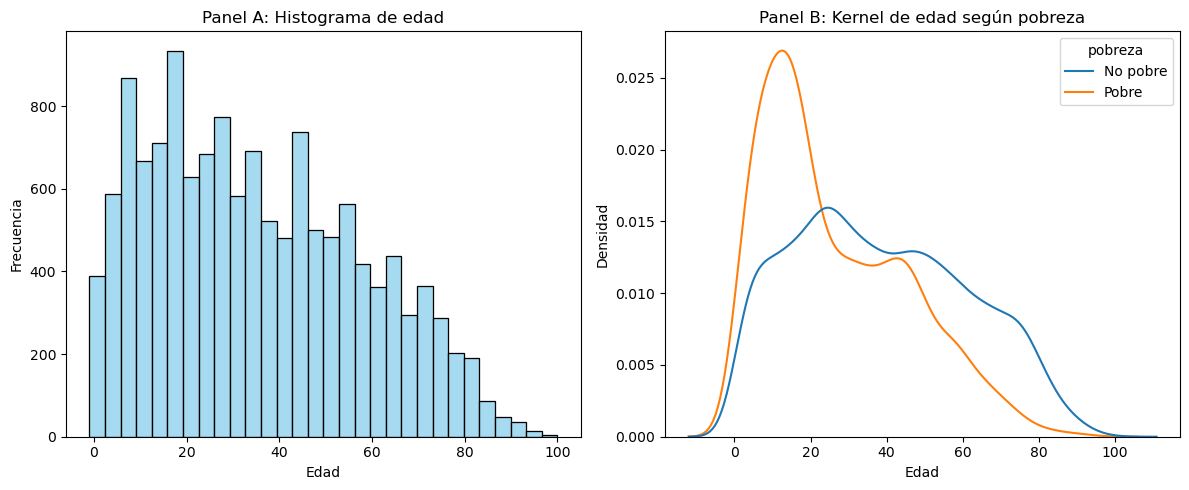

In [16]:
# Crear la variable edad2
df["edad2"] = df["CH06"]**2

# Graficar con etiquetas correctas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Histograma de edad
sns.histplot(df["CH06"], bins=30, kde=False, ax=axes[0], color="skyblue")
axes[0].set_title("Panel A: Histograma de edad")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")

# Panel B: Distribución de kernel por pobreza
sns.kdeplot(data=df, x="CH06", hue=df["pobreza"].map({0: "No pobre", 1: "Pobre"}), ax=axes[1], common_norm=False)
axes[1].set_title("Panel B: Kernel de edad según pobreza")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Densidad")

plt.tight_layout()
plt.show()


PUNTO 2

In [17]:
#CH12: nivel educativo más alto alcanzado (ej. Primario, Secundario, Universitario, etc.).
#CH13: si finalizó ese nivel (Sí/No).
#CH14: último año aprobado dentro de ese nivel.

#Si finalizó el nivel, cuenta todos los años de ese nivel.
#Si no lo finalizó, cuenta hasta el año que aprobó.

In [18]:
niveles = {
    1: 0,   # Sin instrucción
    2: 6,   # Primario
    3: 12,  # Secundario
    4: 14,  # Terciario no universitario (2 años aprox)
    5: 17   # Universitario (5 años aprox)
}

In [19]:
def calcular_educ(row):
    nivel = row["CH12"]
    finalizo = row["CH13"]
    ultimo_anio = row["CH14"]

    if pd.isna(nivel):
        return np.nan

    # Caso sin instrucción
    if nivel == 1:
        return 0

    # Si finalizó el nivel → asignar años totales del nivel
    if finalizo == 1:
        return niveles.get(nivel, np.nan)

    # Si no finalizó → base años previos + último aprobado
    if finalizo == 2:
        if nivel == 2:  # Primario
            return ultimo_anio
        elif nivel == 3:  # Secundario
            return 6 + ultimo_anio
        elif nivel == 4:  # Terciario
            return 12 + ultimo_anio
        elif nivel == 5:  # Universitario
            return 12 + ultimo_anio
    return np.nan

# Crear la variable
df["educ"] = df.apply(calcular_educ, axis=1)


In [20]:
df["educ"].describe([0.5]).rename({
    "mean": "Promedio",
    "std": "Desvío estándar",
    "min": "Mínimo",
    "50%": "Mediana (p50)",
    "max": "Máximo"
})

count              9498.000000
Promedio             10.826595
Desvío estándar      10.011426
Mínimo                0.000000
Mediana (p50)        12.000000
Máximo              111.000000
Name: educ, dtype: float64

PUNTO 3

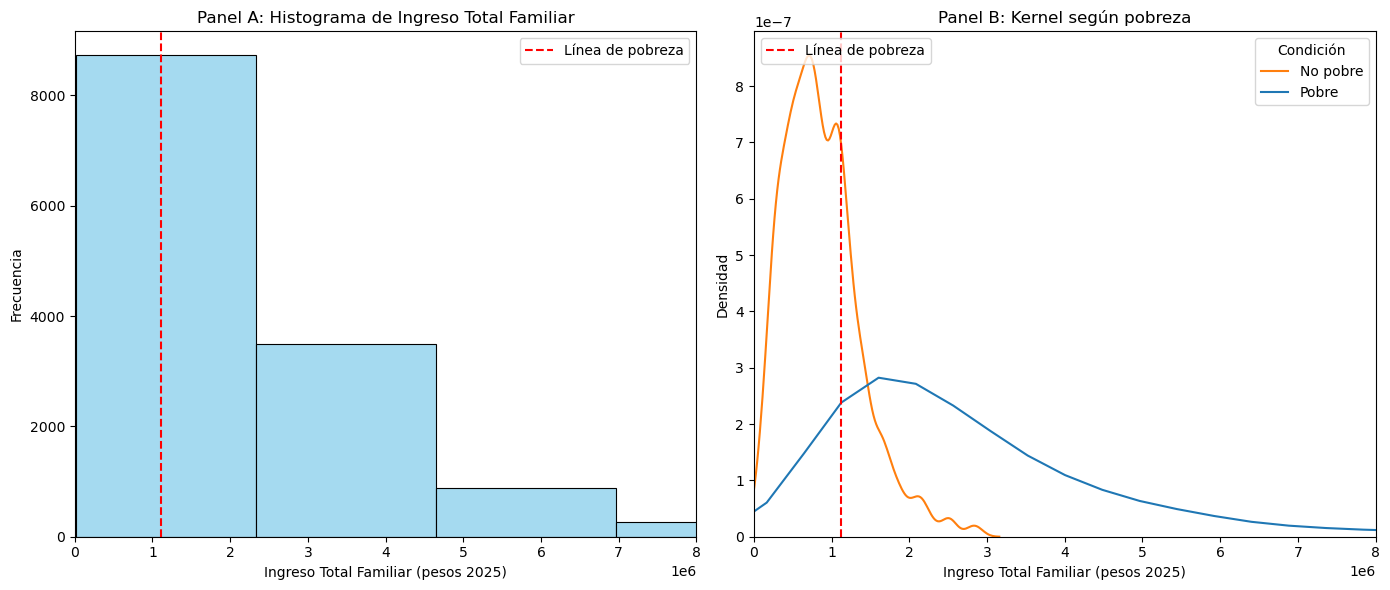

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Crear copia del dataframe original ---
df_punto3 = df.copy()

# --- 1. Actualizar ITF de 2005 a pesos de 2025 ---
factor_conversion = 365177 / 205.07  # CBT 2025 / CBA 2005

df_punto3["ingreso_total_familiar"] = np.where(
    df_punto3["ANO4"] == 2005,
    df_punto3["ITF"] * factor_conversion,  # ajusta ingresos 2005
    df_punto3["ITF"]                       # ingresos 2025 se dejan igual
)

# --- 2. Crear columna ingreso_necesario ---
cba_2025 = 365177
df_punto3["ingreso_necesario"] = cba_2025 * df_punto3["ad_equiv_hogar"]

# --- 3. Variable pobreza (1 = pobre, 0 = no pobre) ---
df_punto3["pobreza"] = np.where(
    df_punto3["ingreso_total_familiar"] < df_punto3["ingreso_necesario"], 1, 0
)

# --- 4. Línea de pobreza (promedio de ingreso_necesario para referencia general) ---
linea_pobreza = df_punto3["ingreso_necesario"].median()

# --- 5. Gráficos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Histograma de ingreso_total_familiar
sns.histplot(df_punto3["ingreso_total_familiar"], bins=40, kde=False, ax=axes[0], color="skyblue")
axes[0].axvline(linea_pobreza, color="red", linestyle="--", label="Línea de pobreza")
axes[0].set_title("Panel A: Histograma de Ingreso Total Familiar")
axes[0].set_xlabel("Ingreso Total Familiar (pesos 2025)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Panel B: Distribución kernel según pobreza
# Panel B: Distribución kernel según pobreza
sns.kdeplot(data=df_punto3, x="ingreso_total_familiar", hue="pobreza", ax=axes[1], common_norm=False)

# --- Leyenda 1: Pobre vs No pobre ---
legend1 = axes[1].legend(title="Condición", labels=["No pobre", "Pobre"], loc="upper right")

# Línea de pobreza
linea = axes[1].axvline(linea_pobreza, color="red", linestyle="--", label="Línea de pobreza")

# --- Leyenda 2: Línea de pobreza ---
legend2 = axes[1].legend(handles=[linea], loc="upper left")

# Fijar la primera leyenda antes de añadir la segunda
axes[1].add_artist(legend1)

axes[1].set_title("Panel B: Kernel según pobreza")
axes[1].set_xlabel("Ingreso Total Familiar (pesos 2025)")
axes[1].set_ylabel("Densidad")
axes[0].set_xlim(0, 8e6)
axes[1].set_xlim(0, 8e6)

plt.tight_layout()
plt.show()

In [43]:
# Asegurá que la columna sea numérica (convierte strings a números)

# Media (promedio) y mediana
media1 = df_punto3["ingreso_total_familiar"].mean()      # ignora NaN por defecto
mediana1 = df_punto3["ingreso_total_familiar"].median()  # ignora NaN por defecto

# Media (promedio) y mediana
media = df_punto3["ingreso_necesario"].mean()      # ignora NaN por defecto
mediana = df_punto3["ingreso_necesario"].median()  # ignora NaN por defecto

print("ITF", media1, mediana1)
print("Ingreso necesario",media, mediana)
print(linea_pobreza) #chequeo visual de la linea de pobreza para que sea coherente. 

ITF 2442488.9177298294 1750000.0
Ingreso necesario 1165565.168266847 1113789.85
1113789.85


PUNTO 4

In [23]:
df_punto3

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,ADECCFR,sexo_std,edad_label,adulto_equiv,ad_equiv_hogar,ingreso_necesario,pobreza,edad2,educ,ingreso_total_familiar
0,125098,1,1.0,1.0,2005,1,1,1,32.0,1017.0,...,5,Varón,más de 75 años,0.74,0.74,270230.98,0,6400.0,14.0,1.038173e+06
1,125188,1,1.0,1.0,2005,1,1,1,32.0,1062.0,...,1,Varón,18 a 29 años,1.02,1.78,650015.06,0,676.0,14.0,8.013344e+05
2,125188,1,2.0,1.0,2005,1,1,1,32.0,1062.0,...,1,Mujer,18 a 29 años,0.76,1.78,650015.06,0,729.0,NaN,8.013344e+05
3,125188,1,3.0,NaN,2005,1,1,1,32.0,1062.0,...,1,Mujer,NaN,NaN,1.78,650015.06,0,NaN,NaN,8.013344e+05
4,125242,1,1.0,1.0,2005,1,1,1,32.0,1103.0,...,7,Mujer,61 a 75 años,0.67,0.67,244668.59,0,5041.0,6.0,1.522535e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16653,TQRMNOUSSHMKPRCDEIJAH00882495,1,3.0,0.0,2025,1,1,S,33.0,2514.0,...,3,Varón,7 años,0.66,3.2,1168566.4,1,49.0,2.0,1.064000e+06
16654,TQRMNOUSSHMKPRCDEIJAH00882495,1,4.0,1.0,2025,1,1,S,33.0,2514.0,...,3,Mujer,15 años,0.77,3.2,1168566.4,1,225.0,16.0,1.064000e+06
16655,TQRMNOPTQHKKPQCDEIJAH00860461,1,1.0,1.0,2025,1,1,S,33.0,1206.0,...,3,Mujer,30 a 45 años,0.77,2.31,843558.87,0,1369.0,NaN,8.600000e+05
16656,TQRMNOPTQHKKPQCDEIJAH00860461,1,2.0,1.0,2025,1,1,S,33.0,1206.0,...,3,Mujer,30 a 45 años,0.77,2.31,843558.87,0,961.0,6.0,8.600000e+05


In [24]:
# Crear variable horastrab solo para jefes de hogar
df_jefe = df_punto3.copy()

df_jefe["horastrab"] = np.where(
    df_jefe["CH03"] == 1,   # CH03 = 1 → Jefe del hogar
    df_jefe["PP3E_TOT"].fillna(0) + df_jefe["PP3F_TOT"].fillna(0),
    np.nan   # para no jefes dejamos NaN
)

# Estadísticas descriptivas
stats_horas = df_jefe["horastrab"].describe([0.5]).rename({
    "mean": "Promedio",
    "std": "Desvío estándar",
    "min": "Mínimo",
    "50%": "Mediana (p50)",
    "max": "Máximo"
})

print(stats_horas)


count              4567.000000
Promedio             30.825925
Desvío estándar      70.882823
Mínimo                0.000000
Mediana (p50)        25.000000
Máximo             1083.000000
Name: horastrab, dtype: float64


PUNTO 5

In [25]:
df_nuevo = df_jefe.copy()
df_nuevo

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,sexo_std,edad_label,adulto_equiv,ad_equiv_hogar,ingreso_necesario,pobreza,edad2,educ,ingreso_total_familiar,horastrab
0,125098,1,1.0,1.0,2005,1,1,1,32.0,1017.0,...,Varón,más de 75 años,0.74,0.74,270230.98,0,6400.0,14.0,1.038173e+06,0.0
1,125188,1,1.0,1.0,2005,1,1,1,32.0,1062.0,...,Varón,18 a 29 años,1.02,1.78,650015.06,0,676.0,14.0,8.013344e+05,20.0
2,125188,1,2.0,1.0,2005,1,1,1,32.0,1062.0,...,Mujer,18 a 29 años,0.76,1.78,650015.06,0,729.0,NaN,8.013344e+05,NaN
3,125188,1,3.0,NaN,2005,1,1,1,32.0,1062.0,...,Mujer,NaN,NaN,1.78,650015.06,0,NaN,NaN,8.013344e+05,NaN
4,125242,1,1.0,1.0,2005,1,1,1,32.0,1103.0,...,Mujer,61 a 75 años,0.67,0.67,244668.59,0,5041.0,6.0,1.522535e+06,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16653,TQRMNOUSSHMKPRCDEIJAH00882495,1,3.0,0.0,2025,1,1,S,33.0,2514.0,...,Varón,7 años,0.66,3.2,1168566.4,1,49.0,2.0,1.064000e+06,NaN
16654,TQRMNOUSSHMKPRCDEIJAH00882495,1,4.0,1.0,2025,1,1,S,33.0,2514.0,...,Mujer,15 años,0.77,3.2,1168566.4,1,225.0,16.0,1.064000e+06,NaN
16655,TQRMNOPTQHKKPQCDEIJAH00860461,1,1.0,1.0,2025,1,1,S,33.0,1206.0,...,Mujer,30 a 45 años,0.77,2.31,843558.87,0,1369.0,NaN,8.600000e+05,0.0
16656,TQRMNOPTQHKKPQCDEIJAH00860461,1,2.0,1.0,2025,1,1,S,33.0,1206.0,...,Mujer,30 a 45 años,0.77,2.31,843558.87,0,961.0,6.0,8.600000e+05,NaN


In [26]:
import pandas as pd
import numpy as np

# --- columnas requeridas ---
req_cols = {"ANO4", "pobreza"}
faltan = req_cols - set(df_nuevo.columns)
if faltan:
    raise ValueError(f"Faltan columnas en df_nuevo: {faltan}")

# Aseguro que ANO4 sea numérico (por si viene como string)
df_nuevo = df_nuevo.copy()
df_nuevo["ANO4"] = pd.to_numeric(df_nuevo["ANO4"], errors="coerce").astype("Int64")

# Años objetivo de la tabla (ajustá si necesitás otros)
anios = [2005, 2025]

# Helper: reindex a [2005, 2025] y llena con 0 si algún año no existe
def _reindex_anos(s):
    return s.reindex(anios, fill_value=0)

# 1) Cantidad de observaciones por año
obs_por_anio = _reindex_anos(df_nuevo.groupby("ANO4").size())

# 2) Cantidad de observaciones con NA en "Pobre" por año
na_pobre_por_anio = _reindex_anos(
    df_nuevo.groupby("ANO4")["pobreza"].apply(lambda s: s.isna().sum())
)

# 3) Cantidad de Pobres (Pobre == 1) por año
pobres_por_anio = _reindex_anos(
    df_nuevo.groupby("ANO4")["pobreza"].apply(lambda s: (s == 1).sum())
)

# 4) Cantidad de No Pobres (Pobre == 0) por año
no_pobres_por_anio = _reindex_anos(
    df_nuevo.groupby("ANO4")["pobreza"].apply(lambda s: (s == 0).sum())
)

# 5) Cantidad de variables limpias y homogeneizadas
#     (número de columnas de df_nuevo; mismo valor para 2005, 2025 y Total)
n_vars = df_nuevo.shape[1]
vars_por_anio = pd.Series({a: n_vars for a in anios})

# Armo la Tabla 1 con columnas 2005, 2025 y Total
tabla1 = pd.DataFrame({
    "2005": [
        obs_por_anio.get(2005, 0),
        na_pobre_por_anio.get(2005, 0),
        pobres_por_anio.get(2005, 0),
        no_pobres_por_anio.get(2005, 0),
        vars_por_anio.get(2005, n_vars),
    ],
    "2025": [
        obs_por_anio.get(2025, 0),
        na_pobre_por_anio.get(2025, 0),
        pobres_por_anio.get(2025, 0),
        no_pobres_por_anio.get(2025, 0),
        vars_por_anio.get(2025, n_vars),
    ],
}, index=[
    "Cantidad de observaciones",
    "Observaciones con NA en 'pobreza'",
    "Cantidad de Pobres",
    "Cantidad de No Pobres",
    "Cantidad de variables limpias y homogeneizadas",
])

# Columna Total (suma de 2005 y 2025, excepto la última fila que es el mismo n_vars)
tabla1["Total"] = tabla1.loc[
    ["Cantidad de observaciones",
     "Observaciones con NA en 'pobreza'",
     "Cantidad de Pobres",
     "Cantidad de No Pobres"], ["2005", "2025"]
].sum(axis=1)
tabla1.loc["Cantidad de variables limpias y homogeneizadas", "Total"] = n_vars

# Opcional: mostrar bonita
print(tabla1)

                                                2005  2025    Total
Cantidad de observaciones                       9371  4309  13680.0
Observaciones con NA en 'pobreza'                  0     0      0.0
Cantidad de Pobres                              2438  1341   3779.0
Cantidad de No Pobres                           6933  2968   9901.0
Cantidad de variables limpias y homogeneizadas   178   178    178.0


Parte II: Métodos No Supervisados 

Subimos las bases de hogares para encontrar las nuevas variables que necesitamos

A. PCA

PUNTO 1

In [27]:
df_cop = df_nuevo.copy()

In [28]:
df_cop["num_hogar"] = df_cop.groupby("CODUSU")["CODUSU"].transform("size")

In [29]:
df_cop

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,edad_label,adulto_equiv,ad_equiv_hogar,ingreso_necesario,pobreza,edad2,educ,ingreso_total_familiar,horastrab,num_hogar
0,125098,1,1.0,1.0,2005,1,1,1,32.0,1017.0,...,más de 75 años,0.74,0.74,270230.98,0,6400.0,14.0,1.038173e+06,0.0,1
1,125188,1,1.0,1.0,2005,1,1,1,32.0,1062.0,...,18 a 29 años,1.02,1.78,650015.06,0,676.0,14.0,8.013344e+05,20.0,3
2,125188,1,2.0,1.0,2005,1,1,1,32.0,1062.0,...,18 a 29 años,0.76,1.78,650015.06,0,729.0,NaN,8.013344e+05,NaN,3
3,125188,1,3.0,NaN,2005,1,1,1,32.0,1062.0,...,NaN,NaN,1.78,650015.06,0,NaN,NaN,8.013344e+05,NaN,3
4,125242,1,1.0,1.0,2005,1,1,1,32.0,1103.0,...,61 a 75 años,0.67,0.67,244668.59,0,5041.0,6.0,1.522535e+06,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16653,TQRMNOUSSHMKPRCDEIJAH00882495,1,3.0,0.0,2025,1,1,S,33.0,2514.0,...,7 años,0.66,3.2,1168566.4,1,49.0,2.0,1.064000e+06,NaN,4
16654,TQRMNOUSSHMKPRCDEIJAH00882495,1,4.0,1.0,2025,1,1,S,33.0,2514.0,...,15 años,0.77,3.2,1168566.4,1,225.0,16.0,1.064000e+06,NaN,4
16655,TQRMNOPTQHKKPQCDEIJAH00860461,1,1.0,1.0,2025,1,1,S,33.0,1206.0,...,30 a 45 años,0.77,2.31,843558.87,0,1369.0,NaN,8.600000e+05,0.0,3
16656,TQRMNOPTQHKKPQCDEIJAH00860461,1,2.0,1.0,2025,1,1,S,33.0,1206.0,...,30 a 45 años,0.77,2.31,843558.87,0,961.0,6.0,8.600000e+05,NaN,3


In [30]:
columnas_nuevas = [ "CH06", "edad2", "educ", "ingreso_total_familiar", "num_hogar", "horastrab"]
df_met = df_cop[columnas_nuevas]

In [31]:
df_met
df_met.to_excel("df_met.xlsx", index = False)

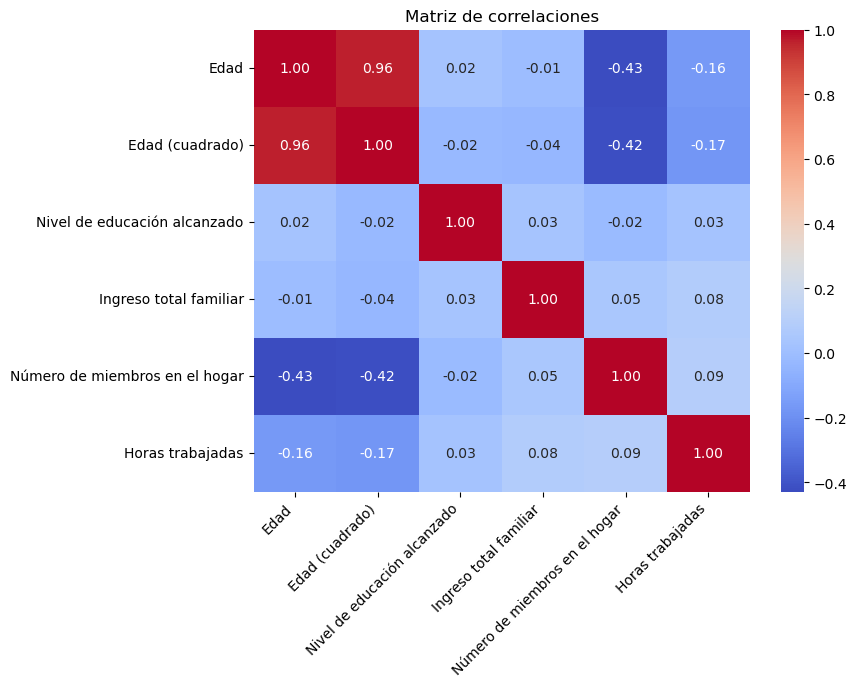

In [32]:

# Diccionario de renombres
renombres = {
    "CH06": "Edad",
    "edad2": "Edad (cuadrado)",
    "educ": "Nivel de educación alcanzado",
    "ingreso_total_familiar": "Ingreso total familiar",
    "num_hogar": "Número de miembros en el hogar",
    "horastrab": "Horas trabajadas"
}

# Renombrar columnas
df_met = df_met.rename(columns=renombres)


# Seleccionar solo las variables de interés
vars_corr = list(renombres.values())
df_corr = df_met[vars_corr]


# Calcular la matriz de correlaciones
corr_matrix = df_corr.corr()

# Mostrar la matriz en consola

# Graficar un mapa de calor para visualizar mejor
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Matriz de correlaciones")
plt.xticks(rotation=45, ha="right")
plt.show()


PUNTO 2

PCA con ingreso: Apliquen PCA a las seis variables seleccionadas 
para esta parte. Recuerde primero estandarizar las variables como 
vimos en la tutorial. En un gráfico de dispersión muestren los índices 
(scores) calculados del primer y segundo componente de PCA y 
comente los resultados.  

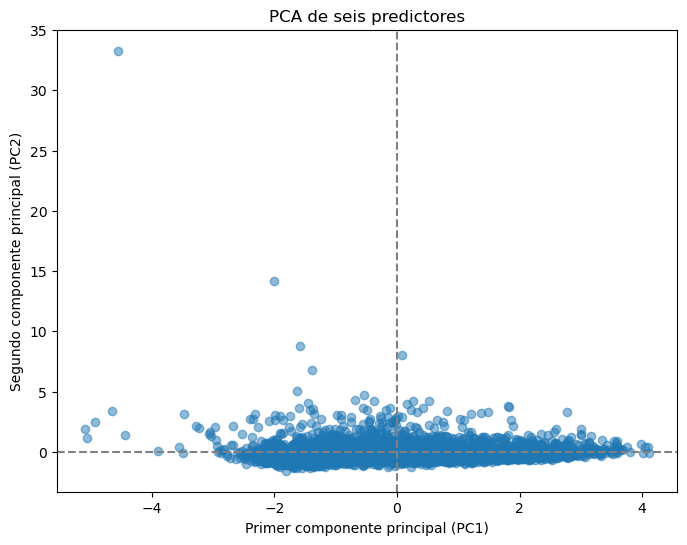

Varianza explicada por PC1 y PC2: [0.38882578 0.17365912]


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Seleccionar variables
vars_pca = [
    "Edad",
    "Edad (cuadrado)",
    "Nivel de educación alcanzado",
    "Ingreso total familiar",
    "Número de miembros en el hogar",
    "Horas trabajadas"
    ]
X = df_met[vars_pca].dropna()   # eliminar filas con NaN

# 1. Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA
pca = PCA(n_components=2)  # nos quedamos con los dos primeros componentes
scores = pca.fit_transform(X_scaled)

# 3. Graficar PC1 vs PC2
plt.figure(figsize=(8,6))
plt.scatter(scores[:,0], scores[:,1], alpha=0.5)
plt.xlabel("Primer componente principal (PC1)")
plt.ylabel("Segundo componente principal (PC2)")
plt.title("PCA de seis predictores")
plt.axhline(0, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")
plt.show()

# 4. Varianza explicada
print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_)


PUNTO 3

In [34]:
df_met

,Edad,Edad (cuadrado),Nivel de educación alcanzado,Ingreso total familiar,Número de miembros en el hogar,Horas trabajadas
0,80.0,6400.0,14.0,1.038173e+06,1,0.0
1,26.0,676.0,14.0,8.013344e+05,3,20.0
2,27.0,729.0,NaN,8.013344e+05,3,NaN
3,NaN,NaN,NaN,8.013344e+05,3,NaN
4,71.0,5041.0,6.0,1.522535e+06,1,0.0
...,...,...,...,...,...,...
16653,7.0,49.0,2.0,1.064000e+06,4,NaN
16654,15.0,225.0,16.0,1.064000e+06,4,NaN
16655,37.0,1369.0,NaN,8.600000e+05,3,0.0
16656,31.0,961.0,6.0,8.600000e+05,3,NaN


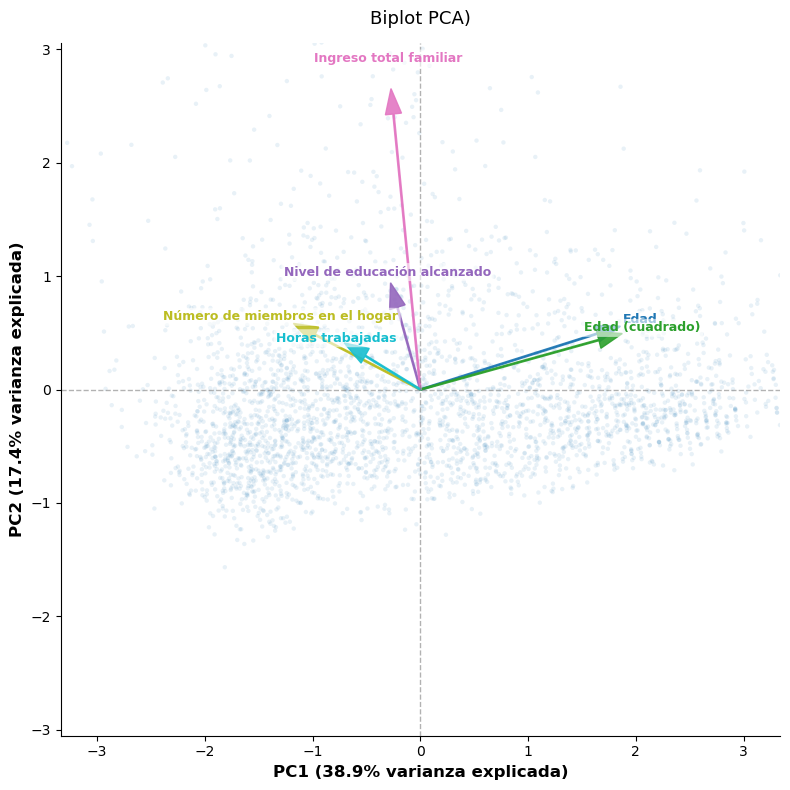

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ===== Config =====
vars_pca = [
    "Edad",
    "Edad (cuadrado)",
    "Nivel de educación alcanzado",
    "Ingreso total familiar",
    "Número de miembros en el hogar",
    "Horas trabajadas"
]
df_met = df_met.copy()

df_met  # <- usa tu df
X = df_met[vars_pca].dropna().copy()

# ===== PCA =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=0)
scores = pca.fit_transform(X_scaled)          # (n,2)
loadings = pca.components_.T                  # (p,2)

# ===== Figura =====
fig, ax = plt.subplots(figsize=(8,8))

# nube (fondo)
ax.scatter(scores[:,0], scores[:,1], s=10, alpha=0.10, edgecolors='none')

# paleta de colores (uno distinto por variable)
colors = plt.cm.tab10(np.linspace(0,1,len(vars_pca)))

# flechas con colores distintos
arrow_scale = 3.0
for i, var in enumerate(vars_pca):
    x, y = loadings[i,0]*arrow_scale, loadings[i,1]*arrow_scale
    ax.arrow(0, 0, x, y, width=0.012, head_width=0.15,
             length_includes_head=True, alpha=0.9, color=colors[i])
    ax.text(x*1.10, y*1.10, var, ha='center', va='center',
            fontsize=9, fontweight="bold", color=colors[i],
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2"))

# ejes guía
ax.axhline(0, color='grey', lw=1, ls='--', alpha=0.6)
ax.axvline(0, color='grey', lw=1, ls='--', alpha=0.6)

# ===== Límites centrados y con zoom controlado =====
# Tomamos el mayor entre: (i) extremo de flechas y (ii) p98 de los scores
Lx = max(np.max(np.abs(loadings[:,0]*arrow_scale))*1.15,
         np.quantile(np.abs(scores[:,0]), 0.98)*1.05)
Ly = max(np.max(np.abs(loadings[:,1]*arrow_scale))*1.15,
         np.quantile(np.abs(scores[:,1]), 0.98)*1.05)

ax.set_xlim(-Lx, Lx)
ax.set_ylim(-Ly, Ly)

# títulos
pc1, pc2 = pca.explained_variance_ratio_[:2]*100
ax.set_title(f"Biplot PCA)", pad=14, fontsize=13)
ax.set_xlabel(f"PC1 ({pc1:.1f}% varianza explicada)", fontsize=12, fontweight="bold")
ax.set_ylabel(f"PC2 ({pc2:.1f}% varianza explicada)", fontsize=12, fontweight="bold")

# estética
for s in ('top','right'):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()


PUNTO 4

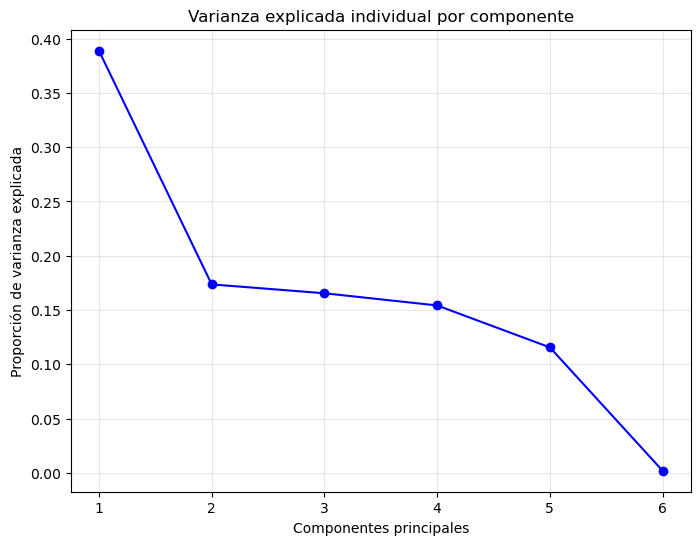

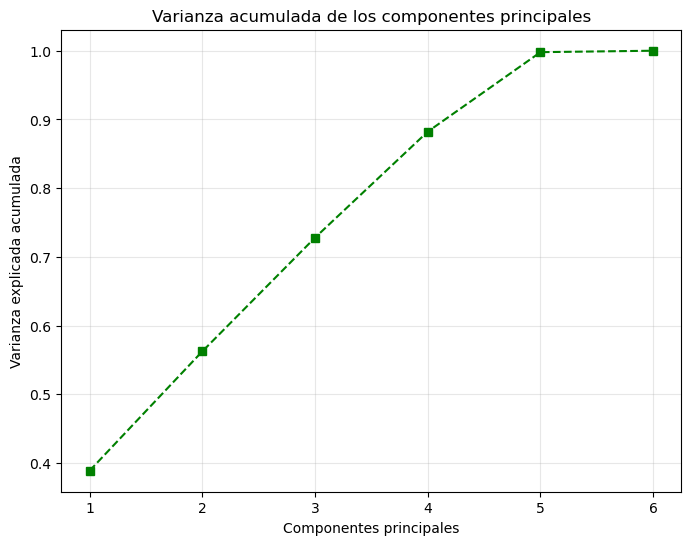

PC1: 0.389
PC2: 0.174
PC3: 0.165
PC4: 0.154
PC5: 0.116
PC6: 0.002


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_met[vars_pca].dropna()

# 1. Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA con todas las componentes
pca = PCA(n_components=6)
pca.fit(X_scaled)

# 3. Varianza explicada
explained_var = pca.explained_variance_ratio_

# --- Gráfico 1: Varianza individual ---
plt.figure(figsize=(8,6))
plt.plot(range(1, 7), explained_var, marker='o', color="blue")
plt.xlabel("Componentes principales")
plt.ylabel("Proporción de varianza explicada")
plt.title("Varianza explicada individual por componente")
plt.xticks(range(1, 7))
plt.grid(alpha=0.3)
plt.show()

# --- Gráfico 2: Varianza acumulada ---
plt.figure(figsize=(8,6))
plt.plot(range(1, 7), explained_var.cumsum(), marker='s', linestyle="--", color="green")
plt.xlabel("Componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza acumulada de los componentes principales")
plt.xticks(range(1, 7))
plt.grid(alpha=0.3)
plt.show()

# Mostrar valores
for i, var in enumerate(explained_var, start=1):
    print(f"PC{i}: {var:.3f}")


B. CLUSTER

PUNTO 5

a. CLuster k-medias

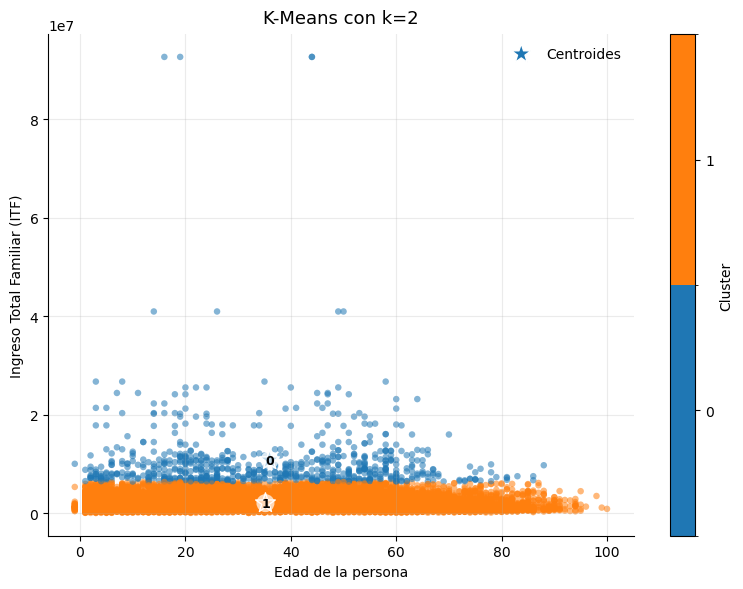

             n  Edad_prom  Ingreso_prom
cluster                                
0          688       36.0    10759513.0
1        12858       35.2     2002208.0


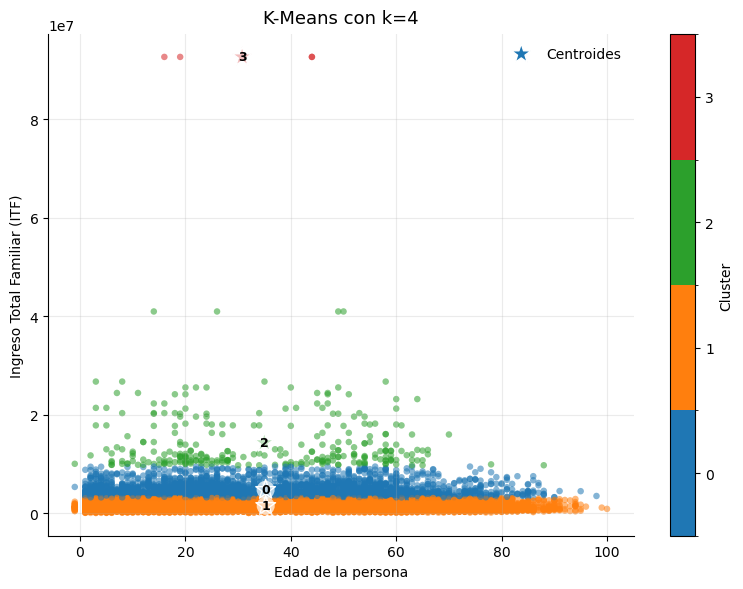

             n  Edad_prom  Ingreso_prom
cluster                                
0         2970       35.2     4708366.0
1        10298       35.2     1444698.0
2          274       35.0    14287742.0
3            4       30.8    92687682.0


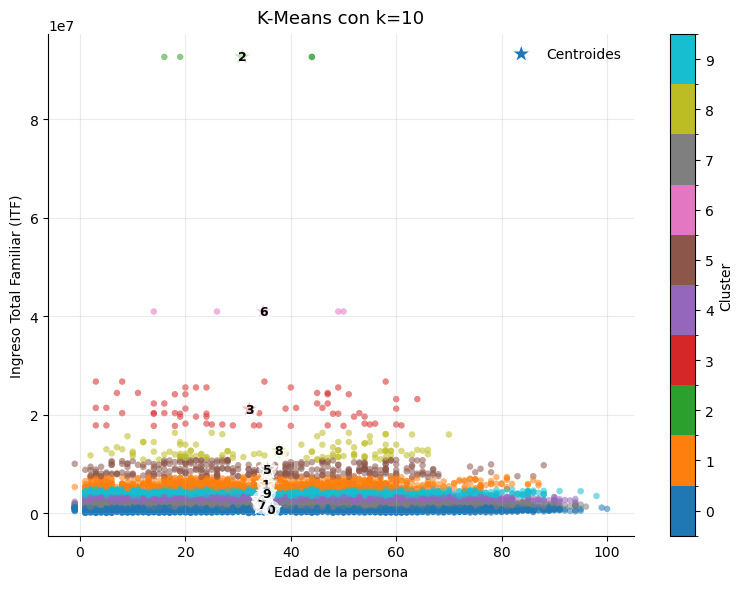

            n  Edad_prom  Ingreso_prom
cluster                               
0        4401       36.3      724498.0
1         829       35.3     5799195.0
2           4       30.8    92687682.0
3          65       32.1    21134288.0
4        2472       34.3     2701422.0
5         310       35.6     8878698.0
6           4       34.8    40957093.0
7        3806       34.4     1636841.0
8         113       37.7    12692031.0
9        1542       35.4     3987192.0


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from sklearn.cluster import KMeans

# Datos (ajusta si usás otro df/columnas)
X = df_met[["Edad", "Ingreso total familiar"]].dropna().copy()
X.columns = ["Edad", "Ingreso"]

def plot_kmeans_lindo(X, k=2, cmap_name="tab10"):
    # K-means
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X.values)
    centers = km.cluster_centers_

    # --- Colores discretos + colorbar bonita ---
    base_cmap = plt.get_cmap(cmap_name)
    cmap = ListedColormap([base_cmap(i) for i in range(k)])
    bounds = np.arange(-0.5, k + 0.5, 1)               # bordes entre clusters
    norm = BoundaryNorm(bounds, cmap.N)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    # --- Figura ---
    fig, ax = plt.subplots(figsize=(8,6))
    sc = ax.scatter(X["Edad"], X["Ingreso"], c=labels, cmap=cmap, norm=norm,
                    s=22, alpha=0.55, edgecolors="none")

   # Centroides coloreados por su propio cluster
    ax.scatter(
        centers[:, 0], centers[:, 1],
        marker="*", s=220,
        c=np.arange(k),           # 0..k-1, uno por cluster
        cmap=cmap, norm=norm,     # mismos que los puntos
        edgecolors="white", linewidths=1.0,
        label="Centroides"
    )

    # (Opcional) numerar los centroides
    for i, (cx, cy) in enumerate(centers):
        ax.text(cx, cy, f"{i}", ha="center", va="center",
                fontsize=9, weight="bold",
                color="black", bbox=dict(boxstyle="circle,pad=0.2", fc="white", ec="none", alpha=0.7))

    # Ejes y estilo
    ax.set_title(f"K-Means con k={k}", fontsize=13, pad=8)
    ax.set_xlabel("Edad de la persona")
    ax.set_ylabel("Ingreso Total Familiar (ITF)")
    ax.grid(True, alpha=0.25)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)

    # Colorbar discreta con ticks 0..k-1 etiquetados como “Cluster i”
    cbar = fig.colorbar(sm, ax=ax, boundaries=bounds, ticks=range(k))
    cbar.set_label("Cluster")
    cbar.ax.set_yticklabels([f"{i}" for i in range(k)])

    # Leyenda de centroides
    ax.legend(frameon=False, loc="best")

    plt.tight_layout()
    plt.show()

    # --- Resumen por cluster (promedios) ---
    out = (pd.DataFrame({"cluster": labels, "Edad": X["Edad"].values, "Ingreso": X["Ingreso"].values})
             .groupby("cluster")
             .agg(n=("Edad","size"),
                  Edad_prom=("Edad","mean"),
                  Ingreso_prom=("Ingreso","mean"))
             .sort_index())
    print(out.round({"Edad_prom":1, "Ingreso_prom":0}))
    return labels, out

# Ejemplos
for k in [2,4,10]:
    labels, resumen = plot_kmeans_lindo(X, k=k)


5b. 

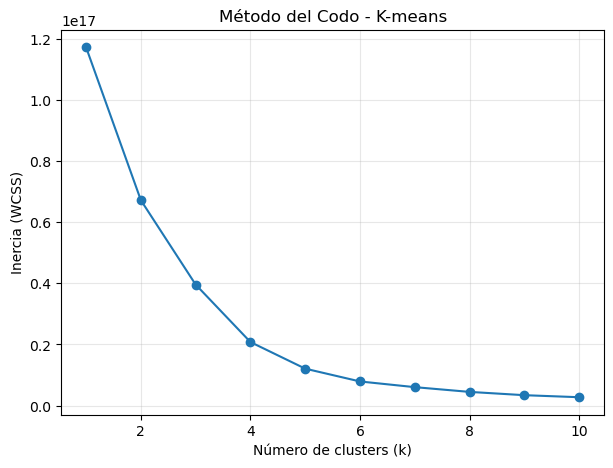

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = df_met[["Edad", "Ingreso total familiar"]].dropna().copy()
X.columns = ["Edad", "Ingreso"]
# Calcular inercia para k=1 a k=10
inercia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

# Graficar Elbow
plt.figure(figsize=(7,5))
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (WCSS)")
plt.title("Método del Codo - K-means")
plt.grid(alpha=0.3)
plt.show()


PUNTO 6

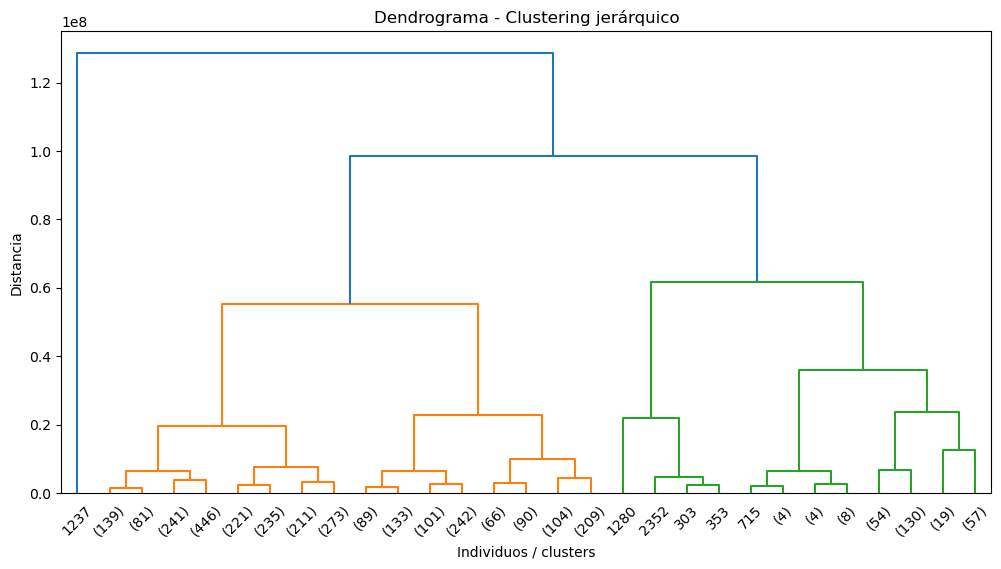

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram



# Variables de interés
X = df_met[[  "Edad",
    "Edad (cuadrado)",
    "Nivel de educación alcanzado",
    "Ingreso total familiar",
    "Número de miembros en el hogar",
    "Horas trabajadas"]].dropna()
 #Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Calcular el linkage (usamos método ward, que minimiza la varianza intra-cluster)
Z = linkage(X, method="ward")

# Graficar dendrograma
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="level", p=5)  # truncar para que sea más legible
plt.title("Dendrograma - Clustering jerárquico")
plt.xlabel("Individuos / clusters")
plt.ylabel("Distancia")
plt.show()
